Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Vocab size: 4000
Train tokens: 281833989

--------------------------------
Testing LR: 1e-05
SP LR 1.0e-05 | step 0 | val 8.4530
SP LR 1.0e-05 | step 50 | val 8.4152
SP LR 1.0e-05 | step 100 | val 8.3417
SP LR 1.0e-05 | step 150 | val 8.2653
SP LR 1.0e-05 | step 200 | val 8.2130

--------------------------------
Testing LR: 3e-05
SP LR 3.0e-05 | step 0 | val 8.3956
SP LR 3.0e-05 | step 50 | val 8.2691
SP LR 3.0e-05 | step 100 | val 8.0937
SP LR 3.0e-05 | step 150 | val 7.8622
SP LR 3.0e-05 | step 200 | val 7.5963

--------------------------------
Testing LR: 0.0001
SP LR 1.0e-04 | step 0 | val 8.4371
SP LR 1.0e-04 | step 50 | val 7.8793
SP LR 1.0e-04 | step 100 | val 6.8148
SP LR 1.0e-04 | step 150 | val 5.6797
SP LR 1.0e-04 | step 200 | val 5.0265

--------------------------------
Testing LR: 0.0003
SP LR 3.0e-04 | step 0 | val 8.3466
SP LR 3.0e-04 | step 50

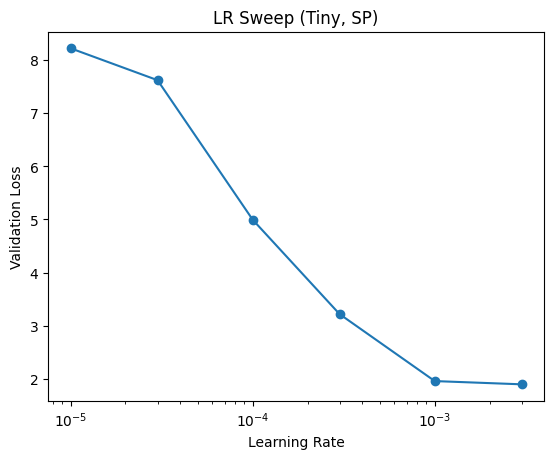


Training SP model: tiny
tiny | step 0 | val 8.4124
tiny | step 50 | val 2.6348
tiny | step 100 | val 2.0307
tiny | step 150 | val 1.8672
tiny | step 200 | val 1.8672
tiny | step 250 | val 1.7748
tiny | step 300 | val 1.7199

Training SP model: small
small | step 0 | val 8.4389
small | step 50 | val 2.3119
small | step 100 | val 1.9345
small | step 150 | val 1.8527
small | step 200 | val 1.7212
small | step 250 | val 1.6690
small | step 300 | val 1.6453

Training SP model: medium
medium | step 0 | val 8.5165
medium | step 50 | val 2.0242
medium | step 100 | val 1.9608
medium | step 150 | val 1.7662
medium | step 200 | val 1.7136
medium | step 250 | val 1.7347
medium | step 300 | val 1.7175

Training SP model: large
large | step 0 | val 8.4237
large | step 50 | val 1.9084
large | step 100 | val 1.8790
large | step 150 | val 1.7166
large | step 200 | val 1.7193
large | step 250 | val 1.8796
large | step 300 | val 1.7891

Training SP model: xl
xl | step 0 | val 8.4270
xl | step 50 | val 1

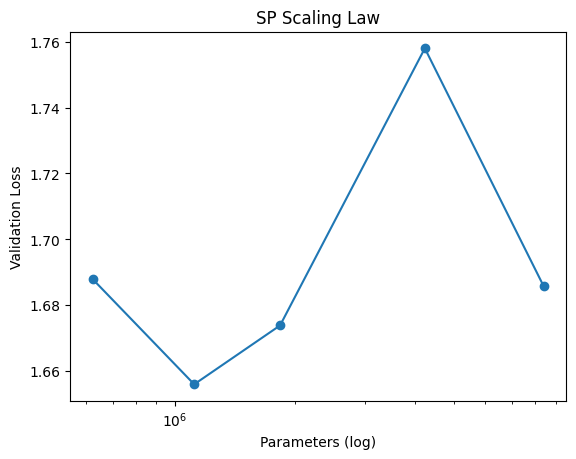

Scaling exponent alpha: -0.009277003237609653


In [32]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Colab Notebooks/ML/svg_data_outputs"

import torch, torch.nn as nn, torch.nn.functional as F
import random, math, time
import numpy as np
import matplotlib.pyplot as plt
from tokenizers import Tokenizer

tokenizer    = Tokenizer.from_file(base_path + "/svg_tokenizer.json")
train_tokens = torch.load(base_path + "/train_tokens.pt")
val_tokens   = torch.load(base_path + "/val_tokens.pt")
test_tokens  = torch.load(base_path + "/test_tokens.pt")

print("Vocab size:", tokenizer.get_vocab_size())
print("Train tokens:", sum(len(x) for x in train_tokens))

class TinyConfig:
    block_size = 128
    vocab_size = tokenizer.get_vocab_size()
    n_layer = 2
    n_head  = 2
    n_embd  = 64
    dropout = 0.1
    ff_mult = 4

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn  = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj  = nn.Linear(config.n_embd, config.n_embd)
        self.n_head  = config.n_head
        self.dropout = nn.Dropout(config.dropout)
        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(C, dim=2)
        head_size = C // self.n_head
        q = q.view(B, T, self.n_head, head_size).transpose(1, 2)
        k = k.view(B, T, self.n_head, head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, head_size).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / (head_size ** 0.5)
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)
        y   = att @ v
        y   = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1  = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln2  = nn.LayerNorm(config.n_embd)
        self.mlp  = nn.Sequential(
            nn.Linear(config.n_embd, config.ff_mult * config.n_embd),
            nn.GELU(),
            nn.Linear(config.ff_mult * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks  = nn.Sequential(*[Block(config) for _ in range(config.n_layer)])
        self.ln_f    = nn.LayerNorm(config.n_embd)
        self.head    = nn.Linear(config.n_embd, config.vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos  = torch.arange(0, T, device=idx.device)
        x    = self.tok_emb(idx) + self.pos_emb(pos)[None, :, :]
        x    = self.blocks(x)
        x    = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

def get_batch(tokens, batch_size, block_size):
    x = torch.zeros((batch_size, block_size), dtype=torch.long)
    y = torch.zeros((batch_size, block_size), dtype=torch.long)
    for i in range(batch_size):
        doc = random.choice(tokens)
        while len(doc) <= block_size + 1:
            doc = random.choice(tokens)
        start = random.randint(0, len(doc) - block_size - 1)
        chunk = doc[start:start + block_size + 1]
        x[i] = torch.tensor(chunk[:-1])
        y[i] = torch.tensor(chunk[1:])
    return x, y

@torch.no_grad()
def evaluate(model, val_tokens, config, steps=20):
    device = next(model.parameters()).device
    model.eval()
    losses = []
    for _ in range(steps):
        x, y = get_batch(val_tokens, 4, config.block_size)
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

def train_tiny_lr(lr, train_tokens, val_tokens, config):
    print("\n--------------------------------")
    print(f"Testing LR: {lr}")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = GPT(config).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)
    steps = 200
    warmup_steps = 20

    for step in range(steps + 1):
        cur_lr = lr * min(1.0, step / warmup_steps)
        for pg in optimizer.param_groups:
            pg['lr'] = cur_lr

        x, y = get_batch(train_tokens, 4, config.block_size)
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 50 == 0:
            val_loss = evaluate(model, val_tokens, config)
            print(f"SP LR {lr:.1e} | step {step} | val {val_loss:.4f}")

    return evaluate(model, val_tokens, config)

config = TinyConfig()
lrs = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
results = {lr: train_tiny_lr(lr, train_tokens, val_tokens, config) for lr in lrs}

best_lr = min(results, key=results.get)
print("\nBEST SP LR:", best_lr)

plt.figure()
plt.xscale("log")
plt.plot(lrs, [results[lr] for lr in lrs], marker="o")
plt.title("LR Sweep (Tiny, SP)")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Loss")
plt.show()

class ModelConfig:
    def __init__(self, d_model, n_layer, n_head):
        self.block_size = 128
        self.vocab_size = tokenizer.get_vocab_size()
        self.n_embd  = d_model
        self.n_layer = n_layer
        self.n_head  = n_head
        self.dropout = 0.1
        self.ff_mult = 4

model_configs = {
    "tiny":   ModelConfig(64, 2, 2),
    "small":  ModelConfig(96, 3, 3),
    "medium": ModelConfig(128, 4, 4),
    "large":  ModelConfig(192, 6, 6),
    "xl":     ModelConfig(256, 8, 8),
}

def train_model(name, config, train_tokens, val_tokens, lr):
    print(f"\nTraining SP model: {name}")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = GPT(config).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    steps = 300
    warmup_steps = 20

    train_losses, val_losses = [], []

    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()
    start = time.time()

    for step in range(steps + 1):
        cur_lr = lr * min(1.0, step / warmup_steps)
        for pg in optimizer.param_groups:
            pg['lr'] = cur_lr

        x, y = get_batch(train_tokens, 4, config.block_size)
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        if step % 50 == 0:
            val_loss = evaluate(model, val_tokens, config)
            val_losses.append(val_loss)
            print(f"{name} | step {step} | val {val_loss:.4f}")

    end = time.time()
    epoch_time = end - start
    current_batch_size = 4
    current_block_size = config.block_size
    tokens_per_step = current_batch_size * current_block_size
    tokens_processed = steps * tokens_per_step
    throughput = tokens_processed / epoch_time if epoch_time > 0 else 0
    max_mem = torch.cuda.max_memory_allocated() / 1e9 if device == "cuda" else 0

    final_val = evaluate(model, val_tokens, config)
    return {
        "params": sum(p.numel() for p in model.parameters()),
        "final_val": final_val,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "time": epoch_time,
        "throughput": throughput,
        "memory": max_mem
    }

results_sp = {}
for name in model_configs:
    res = train_model(name, model_configs[name], train_tokens, val_tokens, best_lr)
    results_sp[name] = res

params = [results_sp[n]["params"] for n in results_sp]
losses = [results_sp[n]["final_val"] for n in results_sp]

plt.figure()
plt.xscale("log")
plt.plot(params, losses, "o-")
plt.xlabel("Parameters (log)")
plt.ylabel("Validation Loss")
plt.title("SP Scaling Law")
plt.show()

from scipy.optimize import curve_fit

def power_law(N, a, alpha):
    return a * (N ** (-alpha))

params_np = np.array(params, dtype=float)
loss_np   = np.array(losses, dtype=float)

popt, _ = curve_fit(power_law, params_np, loss_np, p0=[loss_np[0], 0.1], maxfev=10000)
print("Scaling exponent alpha:", popt[1])

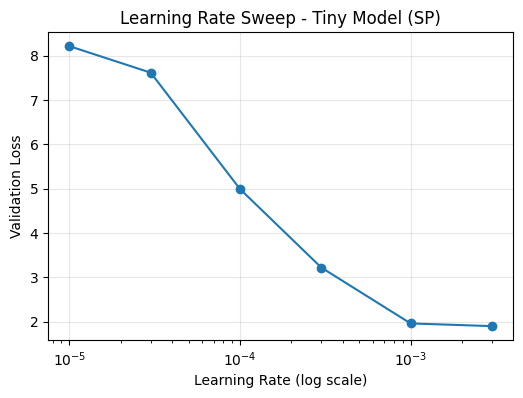

In [33]:
# LR Sweep Plot (SP)
lrs_sorted   = sorted(results.keys())
final_losses = [results[lr] for lr in lrs_sorted]

plt.figure(figsize=(6,4))
plt.xscale("log")
plt.plot(lrs_sorted, final_losses, marker="o")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Validation Loss")
plt.title("Learning Rate Sweep - Tiny Model (SP)")
plt.grid(True, alpha=0.3)
plt.show()

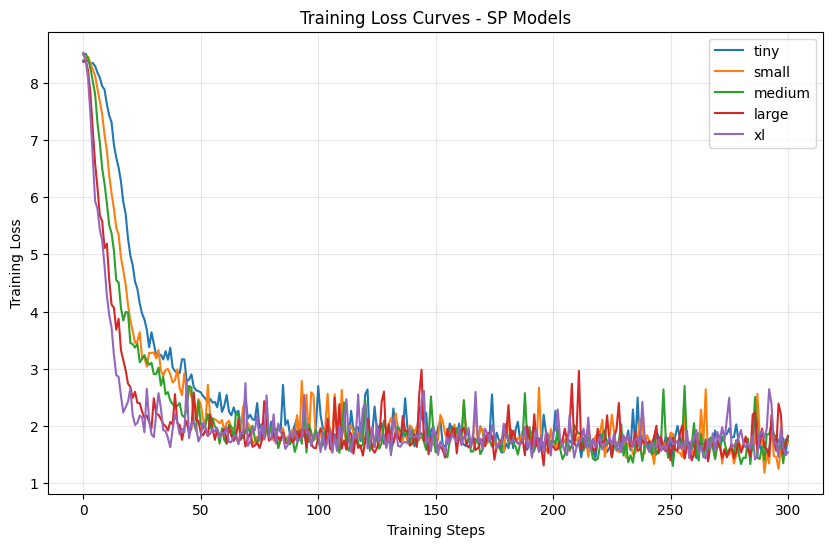

In [34]:
plt.figure(figsize=(10,6))
for name in results_sp:
    plt.plot(results_sp[name]["train_losses"], label=name)
plt.xlabel("Training Steps")
plt.ylabel("Training Loss")
plt.title("Training Loss Curves - SP Models")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


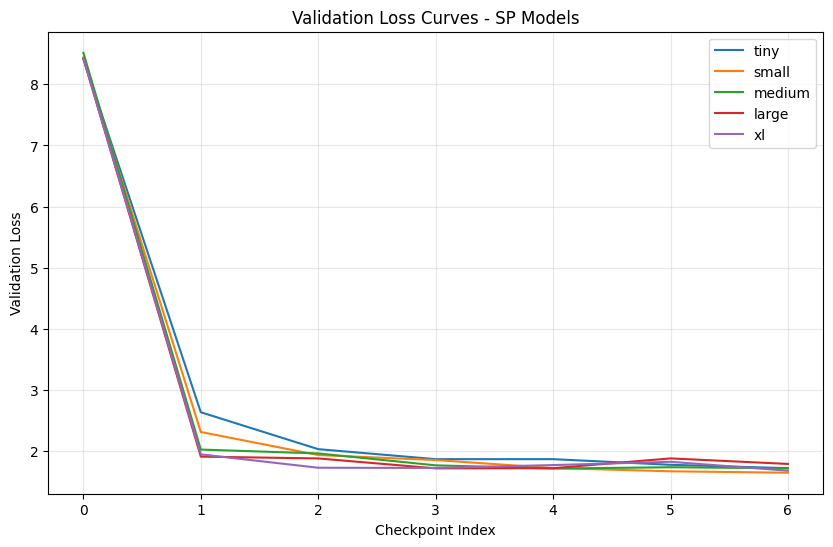

In [35]:
plt.figure(figsize=(10,6))
for name in results_sp:
    plt.plot(results_sp[name]["val_losses"], label=name)
plt.xlabel("Checkpoint Index")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curves - SP Models")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


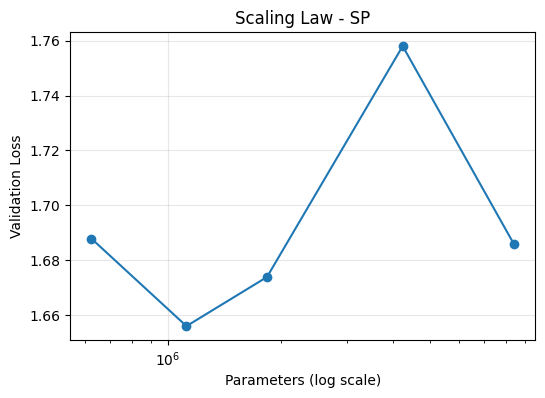

In [36]:
# Scaling Law — SP (already computed: params, losses)
plt.figure(figsize=(6,4))
plt.xscale("log")
plt.plot(params, losses, "o-", label="SP")
plt.xlabel("Parameters (log scale)")
plt.ylabel("Validation Loss")
plt.title("Scaling Law - SP")
plt.grid(True, alpha=0.3)
plt.show()

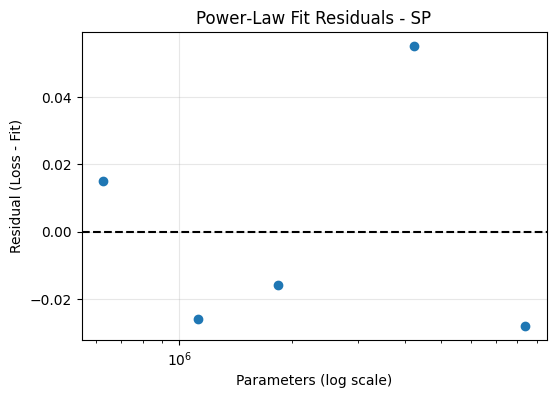

In [37]:
# Power‑law fit residuals - SP
pred = power_law(params_np, *popt)
residuals = loss_np - pred

plt.figure(figsize=(6,4))
plt.scatter(params_np, residuals)
plt.xscale("log")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Parameters (log scale)")
plt.ylabel("Residual (Loss - Fit)")
plt.title("Power‑Law Fit Residuals - SP")
plt.grid(True, alpha=0.3)
plt.show()

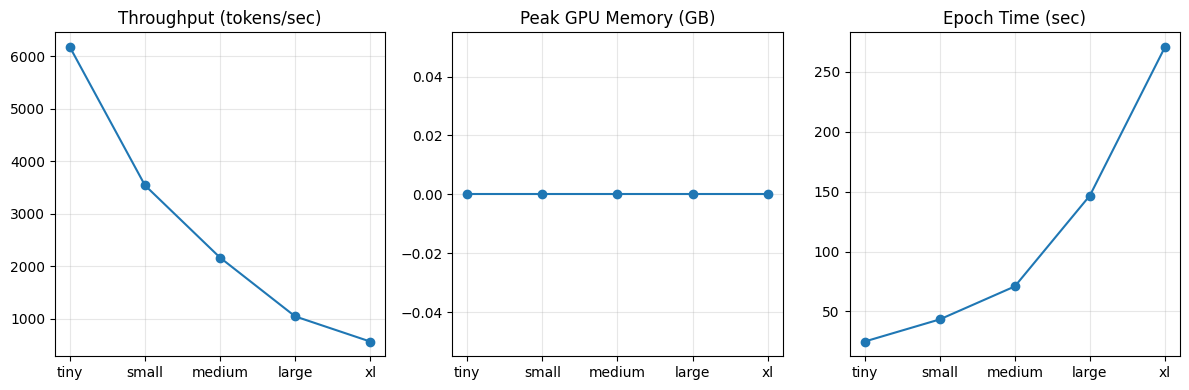

In [38]:
names = list(results_sp.keys())
throughput = [results_sp[n]["throughput"] for n in names]
memory     = [results_sp[n]["memory"] for n in names]
times      = [results_sp[n]["time"] for n in names]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(names, throughput, marker="o")
plt.title("Throughput (tokens/sec)")
plt.grid(True, alpha=0.3)

plt.subplot(1,3,2)
plt.plot(names, memory, marker="o")
plt.title("Peak GPU Memory (GB)")
plt.grid(True, alpha=0.3)

plt.subplot(1,3,3)
plt.plot(names, times, marker="o")
plt.title("Epoch Time (sec)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


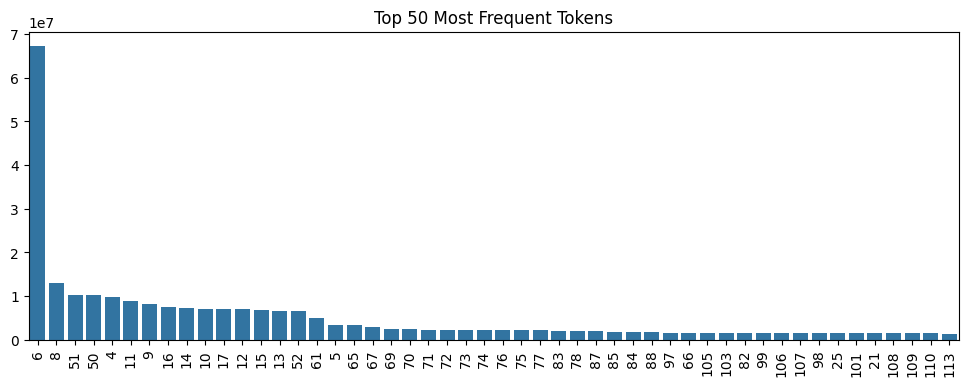

In [39]:
from collections import Counter
import seaborn as sns

all_tokens = [t for seq in train_tokens for t in seq]
counts = Counter(all_tokens)
top50 = counts.most_common(50)

labels = [str(t[0]) for t in top50]
values = [t[1] for t in top50]

plt.figure(figsize=(12,4))
sns.barplot(x=labels, y=values)
plt.xticks(rotation=90)
plt.title("Top 50 Most Frequent Tokens")
plt.show()
